# Predictive Modeling with Linear Regression Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.

### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.

### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# Importing Necessary Libraries
#Libraries used for reading and Manipulating data
import pandas as pd 
import numpy as np
# Libraries used for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # used for splitting data into train and test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # used to check model performance
import statsmodels.api as sm # used to build linear regression model



## Loading the dataset

In [3]:
Recell_data= pd.read_csv("used_device_data.csv")
Recell_data.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


## Data Overview

- Observations
- Sanity checks

In [4]:
Recell_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

#### Observation

The ReCell dataset contains 3,454 observations and 15 variables.It includes 9 float, 2 integer, and 4 categorical (object) variables. Missing values are present in several numerical columns, including main_camera_mp, selfie_camera_mp, int_memory, ram, battery, and weight, while the categorical variables contain no missing values.

In [10]:
Recell_data.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


#### Observation

The descriptive statistics show that the dataset contains 3,454 mobile devices with a mix of categorical and numerical features. There are 34 different brands represented, with "Others" being the most frequent category, while Android is the dominant operating system. Most devices support 4G, whereas relatively few support 5G, reflecting the release period of the phones.

Among the numerical variables, devices have an average screen size of 13.71 inches, 4 GB of RAM, 54.57 GB of internal storage, 3,133 mAh battery capacity, and 183 g average weight. The devices were released between 2013 and 2020, with an average release year of 2016, and have been used for an average of approximately 675 days.

The normalized new price has a higher average (5.23) than the normalized used price (4.36), which is expected since used devices are generally sold at lower prices. Several variables, including internal memory, battery capacity, weight, and camera resolution, exhibit large ranges and relatively high standard deviations, indicating considerable variability and the possible presence of outliers. Additionally, a few variables contain a small number of missing values, but the dataset is largely complete.

In [11]:
# Checks for missing values
Recell_data.isnull().sum()

brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64

#### Observation

Most variables have no missing values, indicating that the dataset is generally of good quality.
* The main_camera_mp feature has the highest number of missing values (179), accounting for approximately 5.2% of the dataset.
* The remaining variables—selfie_camera_mp (2), int_memory (4), ram (4), battery (6), and weight (7)—contain very few missing values.
  
Since the proportion of missing values is low overall, appropriate imputation techniques can be applied instead of dropping the affected records, thereby preserving most of the available data.

In [13]:
# Duplicate records
Recell_data.duplicated().sum()

0

The ReCell dataset contains no duplicate records, indicating that each observation is unique and no duplicate entries need to be removed before analysis.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

### Univariant Analysis 


In [15]:
# Separate Numerical and Categorical columns
num_cols = Recell_data.select_dtypes(include=np.number).columns

cat_cols = Recell_data.select_dtypes(include='object').columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory',
       'ram', 'battery', 'weight', 'release_year', 'days_used',
       'normalized_used_price', 'normalized_new_price'],
      dtype='object')

Categorical Columns:
Index(['brand_name', 'os', '4g', '5g'], dtype='object')


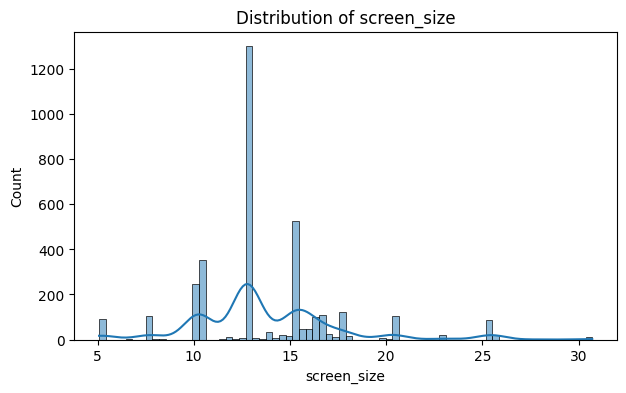

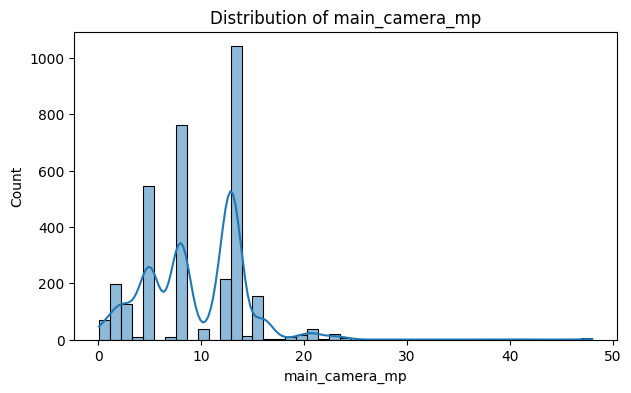

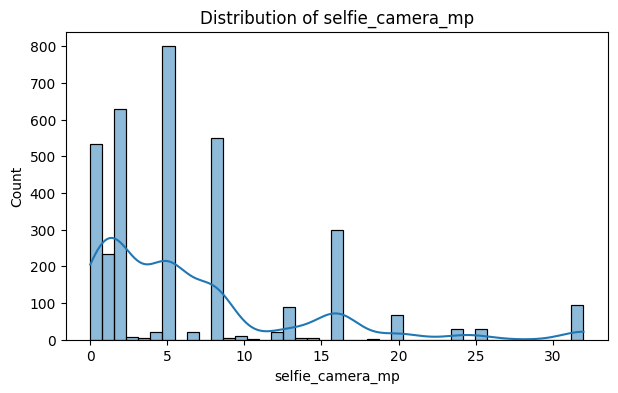

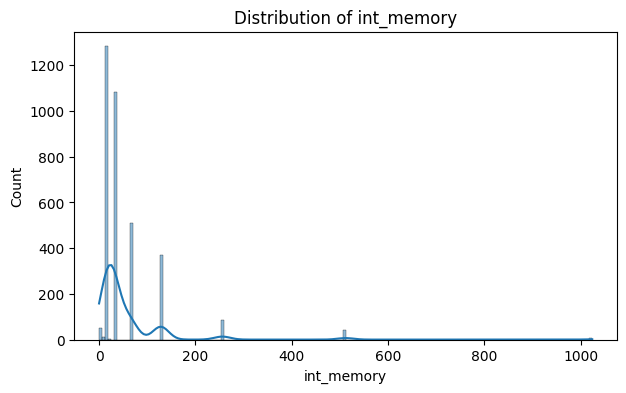

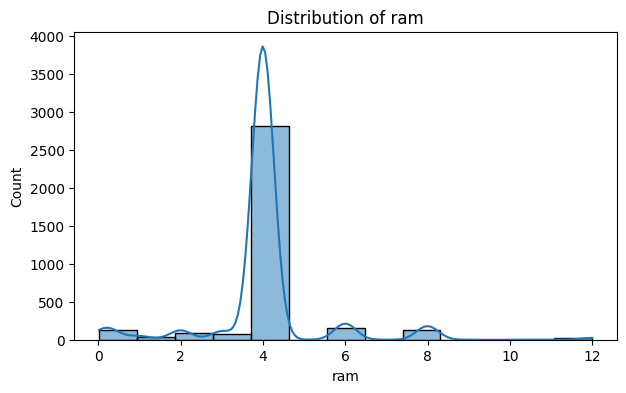

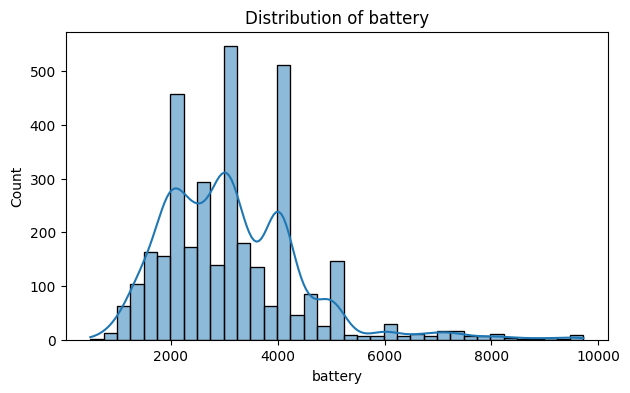

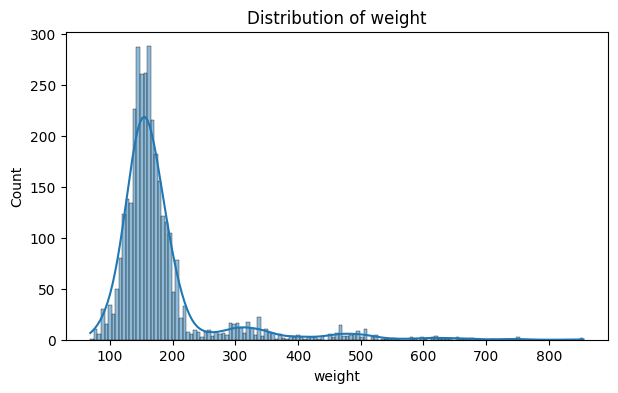

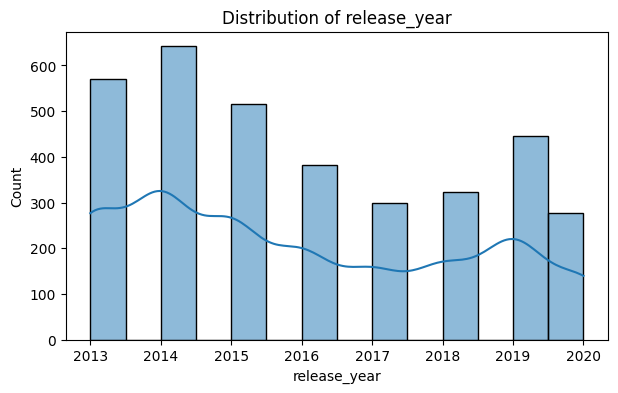

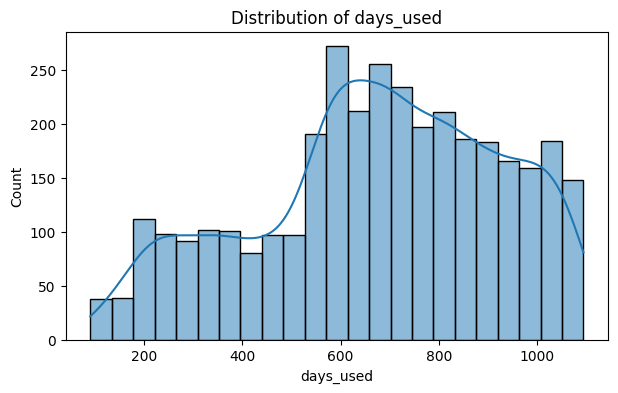

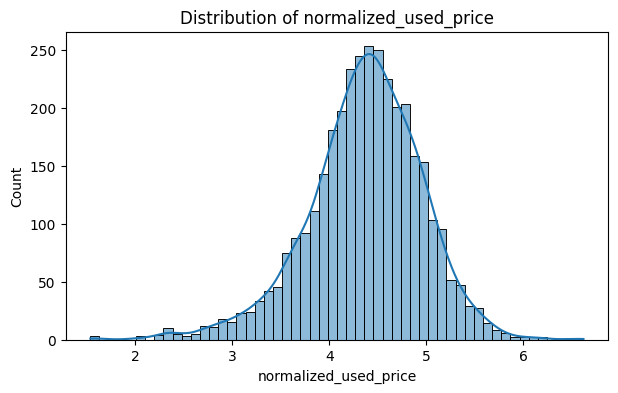

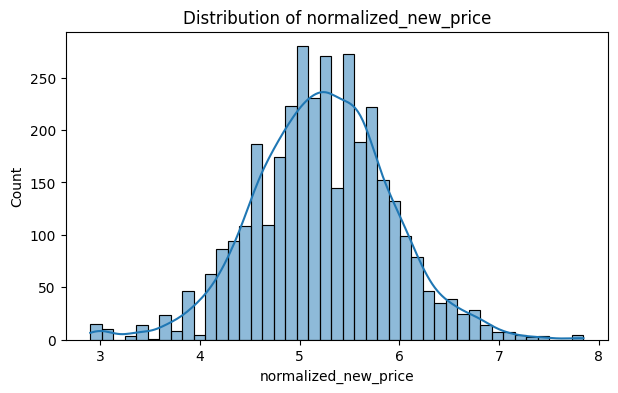

In [17]:
# Distribution of Numerical Variables
for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(Recell_data[col], kde=True)

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.show()

### Observations from the Distribution of Numerical Variables

- Most hardware specification variables, including main camera resolution, selfie camera resolution, internal memory, battery capacity, and weight, exhibit right-skewed distributions, indicating that most devices have moderate specifications while a small number of premium devices possess substantially higher values.
- Screen size displays a multimodal distribution, reflecting the presence of different device categories, primarily smartphones and tablets.
- RAM and internal memory are concentrated around a few standard configurations, suggesting that manufacturers commonly produce devices with specific memory capacities.
- Release years range from 2013 to 2020, providing a good representation of devices across multiple generations, while most devices have been used for a moderate duration.
- Both normalized used price and normalized new price are approximately normally distributed, making them suitable for linear regression modeling.
- Several numerical variables contain extreme values, particularly for storage, battery capacity, camera resolution, and weight. These values likely represent premium or specialized devices rather than data quality issues.

Overall, the numerical variables capture a wide range of device specifications and market segments, from entry-level to premium models. The presence of both normally distributed price variables and realistic variation in device characteristics provides a strong foundation for exploratory analysis and subsequent regression modeling.

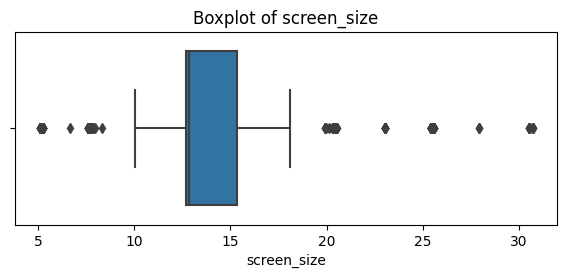

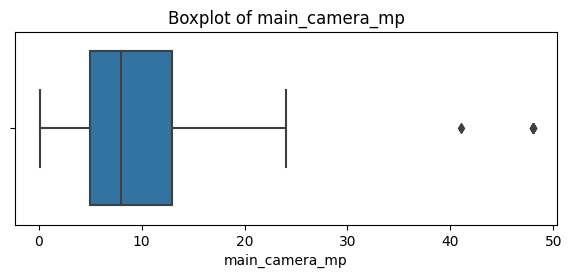

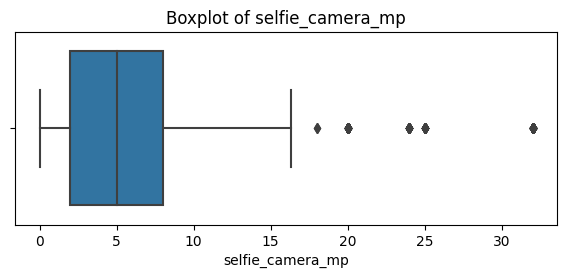

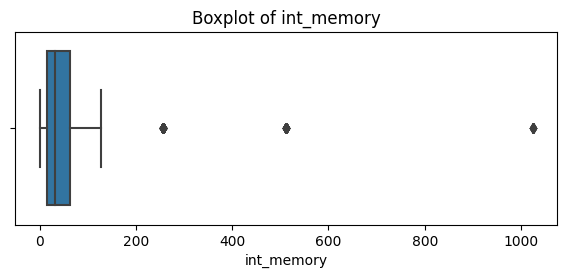

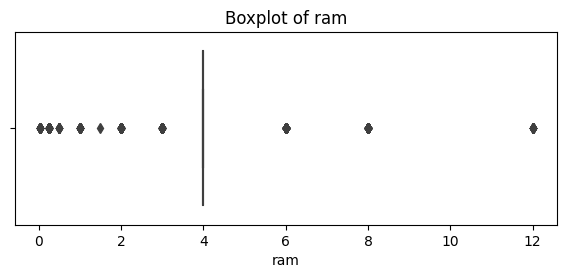

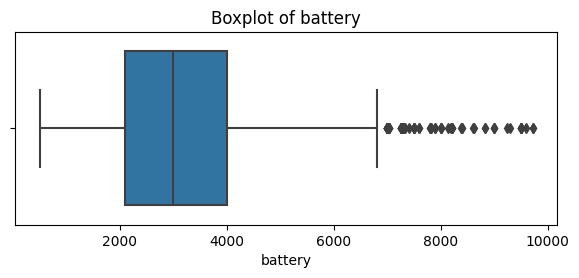

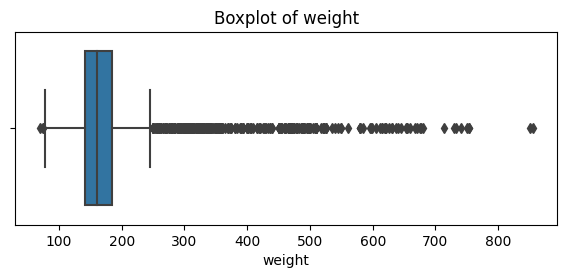

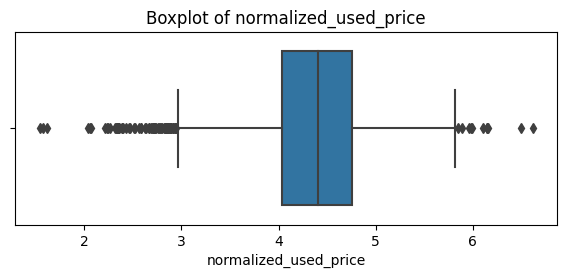

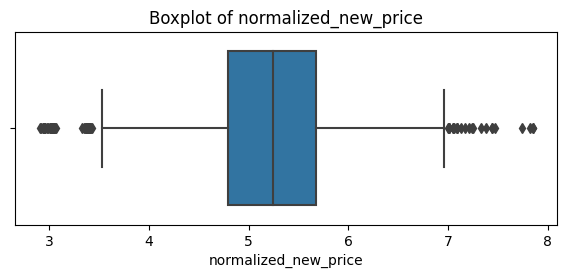

In [28]:
# # Boxplots for Outlier Detection

outlier_cols = [
    "screen_size",
    "main_camera_mp",
    "selfie_camera_mp",
    "int_memory",
    "ram",
    "battery",
    "weight",
    "normalized_used_price",
    "normalized_new_price"
]

for col in outlier_cols:
    plt.figure(figsize=(7, 2.5))
    sns.boxplot(x=Recell_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Observations from the Boxplots (Outlier Analysis)

- Most numerical variables exhibit outliers, particularly hardware specifications such as screen size, camera resolution, internal memory, battery capacity, weight, and both new and used prices. These outliers are expected, as they represent premium or specialized devices rather than data entry errors.
- The distributions of RAM, internal memory, battery capacity, and camera resolutions are right-skewed, with a small number of high-end devices having substantially larger specifications than the majority of the dataset.
- Screen size and weight show a wide range of values, reflecting the presence of both smartphones and tablets in the dataset.
- Both normalized new price and normalized used price contain outliers at the upper and lower ends, indicating the presence of both budget and premium devices in the market.

Overall, the identified outliers appear to represent genuine variations in device specifications and market segments rather than data entry errors. Since these observations correspond to legitimate premium and specialized devices, they were retained to preserve the natural variability of the dataset and ensure that the regression model captures the full range of used device prices.

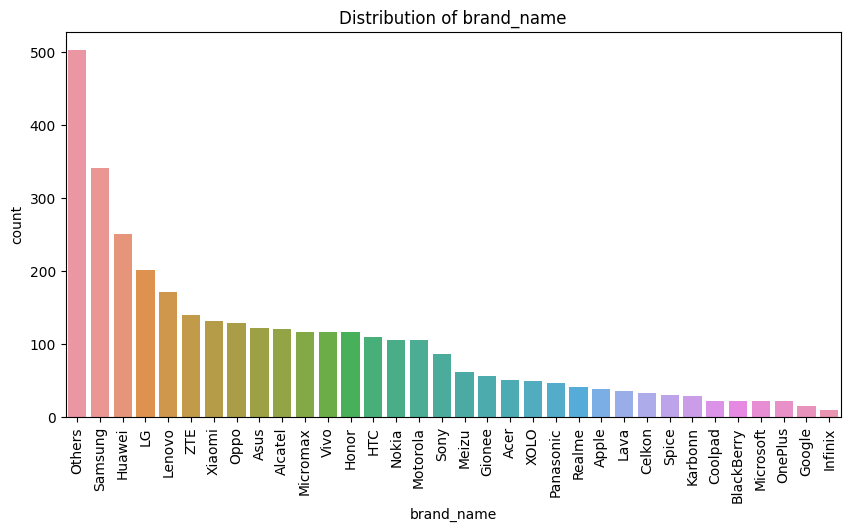

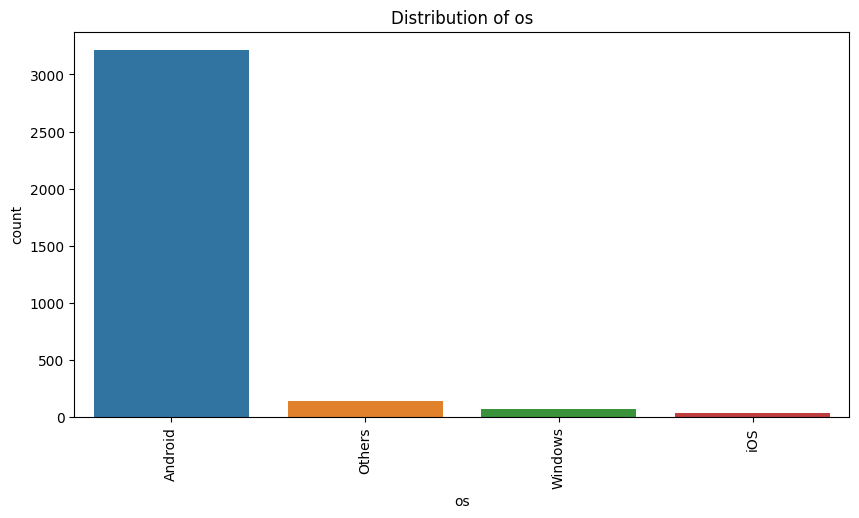

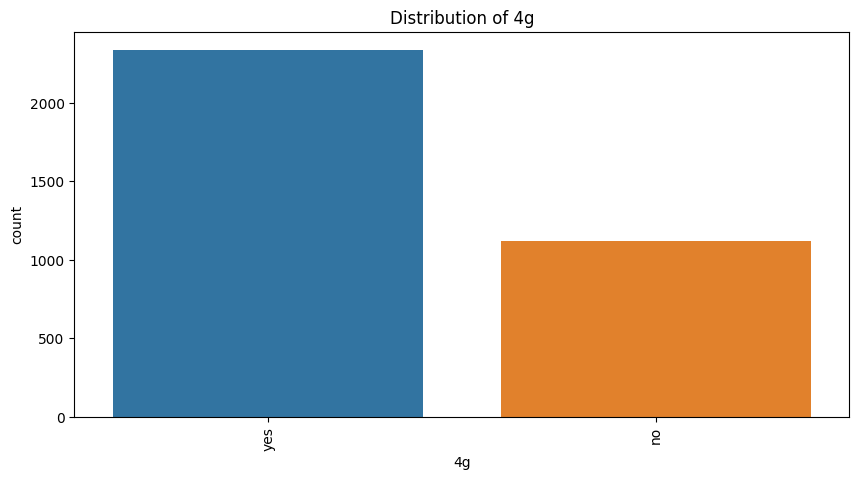

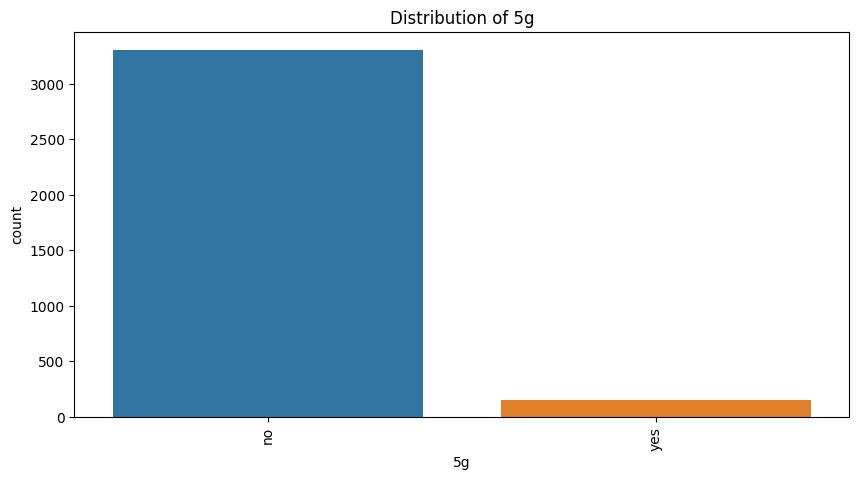

In [21]:
# Distribution of categorical variables
for col in cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=Recell_data,
        x=col,
        order=Recell_data[col].value_counts().index
    )

    plt.xticks(rotation=90)

    plt.title(f'Distribution of {col}')

    plt.show()

### Observations from the Categorical Variables

- The dataset contains a diverse range of device manufacturers, with the **Others** category representing the largest share, followed by Samsung and Huawei. Most other brands have relatively few devices, indicating an uneven distribution across manufacturers.
- Android is by far the most common operating system, while iOS, Windows, and other operating systems have limited representation. This reflects the dominance of Android devices in the used device market.
- Most devices support 4G connectivity, indicating that 4G-enabled devices are significantly more common than those without 4G support.
- Only a small proportion of devices support 5G, which is consistent with the dataset's collection period when 5G technology was still in its early stages of adoption.
- The uneven distribution of operating systems and network technologies suggests that some categorical variables, particularly `5g`, may have limited predictive power individually but could still contribute to the regression model when combined with other device specifications.

Overall, the categorical variables reveal a market dominated by Android devices with broad brand diversity and widespread 4G adoption, while 5G-enabled devices remain relatively uncommon. These characteristics provide useful context for understanding the factors that may influence the resale price of used devices.

In [22]:
# Percentage Distribution of Categorical Variables
for col in cat_cols:

    print(f"\n{col}")

    display(
        (Recell_data[col].value_counts(normalize=True)*100)
        .round(2)
    )


brand_name


Others        14.53
Samsung        9.87
Huawei         7.27
LG             5.82
Lenovo         4.95
ZTE            4.05
Xiaomi         3.82
Oppo           3.73
Asus           3.53
Alcatel        3.50
Micromax       3.39
Vivo           3.39
Honor          3.36
HTC            3.18
Nokia          3.07
Motorola       3.07
Sony           2.49
Meizu          1.80
Gionee         1.62
Acer           1.48
XOLO           1.42
Panasonic      1.36
Realme         1.19
Apple          1.13
Lava           1.04
Celkon         0.96
Spice          0.87
Karbonn        0.84
Coolpad        0.64
BlackBerry     0.64
Microsoft      0.64
OnePlus        0.64
Google         0.43
Infinix        0.29
Name: brand_name, dtype: float64


os


Android    93.05
Others      3.97
Windows     1.94
iOS         1.04
Name: os, dtype: float64


4g


yes    67.6
no     32.4
Name: 4g, dtype: float64


5g


no     95.6
yes     4.4
Name: 5g, dtype: float64

### Observations from the Percentage Distribution of Categorical Variables

- The dataset contains devices from a wide range of manufacturers, with the **Others** category representing the largest share, followed by Samsung and Huawei. Most individual brands account for only a small proportion of the dataset, indicating a diverse but uneven brand distribution.
- Android is the dominant operating system, accounting for over 90% of the devices, while iOS, Windows, and other operating systems collectively represent only a small fraction of the market.
- Approximately two-thirds of the devices support 4G connectivity, showing that 4G-enabled devices are more common than those without 4G support.
- Only a small percentage of devices support 5G, reflecting the dataset's collection period (2021) when 5G adoption was still relatively limited.
- The highly imbalanced distribution of the operating system and 5G variables suggests that these features may provide limited predictive power individually but could still contribute when combined with other device specifications in the regression model.

Overall, the categorical variables indicate a market dominated by Android devices with broad brand diversity and relatively low 5G adoption. These characteristics provide useful context for understanding the dataset and may influence the prediction of used device prices when incorporated alongside the numerical features.

### Bivariant Analysis - Examines relationship between Variables at a time.


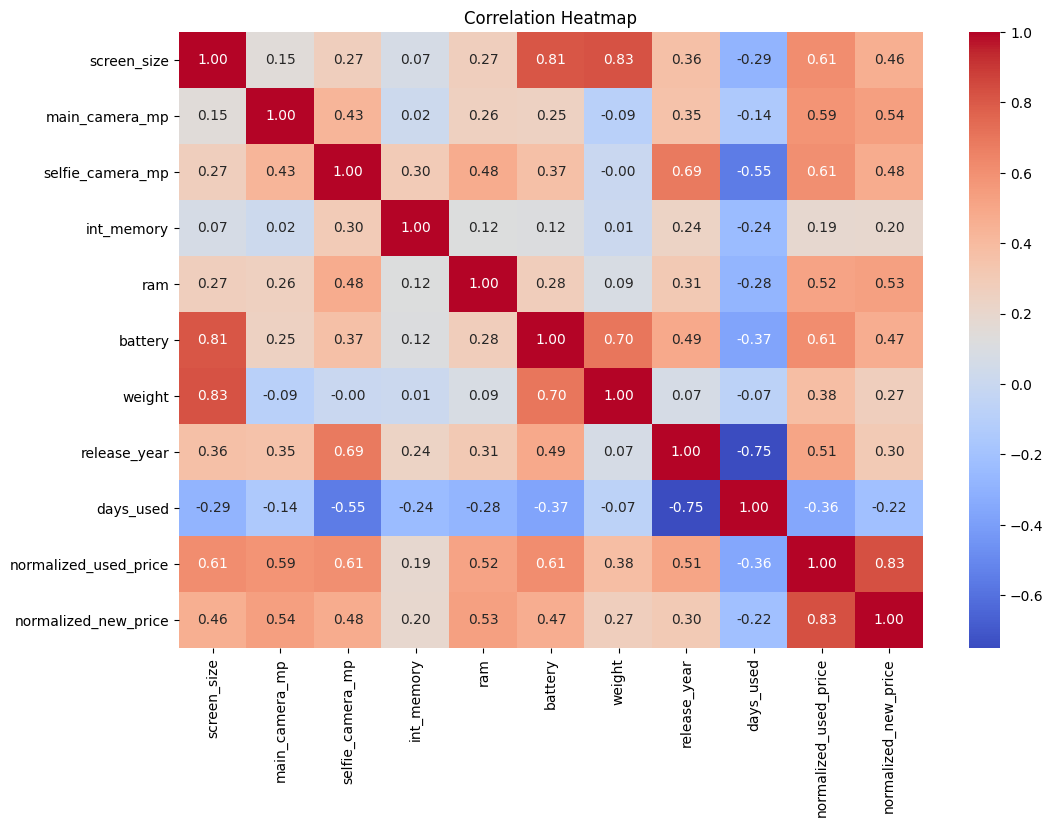

In [23]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    Recell_data[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observations from the Correlation Matrix

- The normalized new price has the strongest positive correlation with the normalized used price, indicating that the original price is the most influential factor in determining a device's resale value.
- Screen size, battery capacity, weight, RAM, and camera resolutions show moderate to strong positive correlations with the normalized used price, suggesting that devices with better hardware specifications generally retain higher resale values.
- Screen size, battery capacity, and weight are highly correlated with one another, indicating that larger devices tend to be heavier and equipped with larger batteries.
- Release year is positively associated with camera quality and negatively correlated with days used, reflecting that newer devices typically have improved specifications and shorter usage periods.
- Days used shows a negative relationship with the normalized used price, supporting the expectation that device value decreases with increased usage over time.
- Internal memory exhibits relatively weak correlations with most variables, indicating that storage capacity alone is not a strong indicator of a device's resale price.
- The presence of strong correlations among some predictor variables, particularly screen size, battery capacity, and weight, suggests that multicollinearity may exist. Therefore, Variance Inflation Factor (VIF) should be evaluated before fitting the multiple linear regression model.

Overall, the correlation analysis indicates that the normalized new price, along with key hardware specifications such as RAM, screen size, battery capacity, and camera quality, are likely to be important predictors of the normalized used price. These findings provide a strong foundation for building the regression model while highlighting the need to assess multicollinearity among the predictor variables.

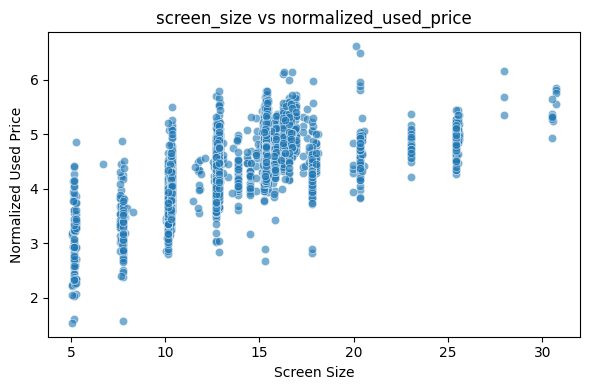

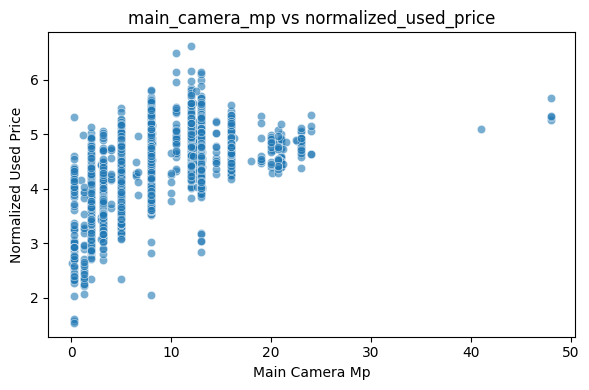

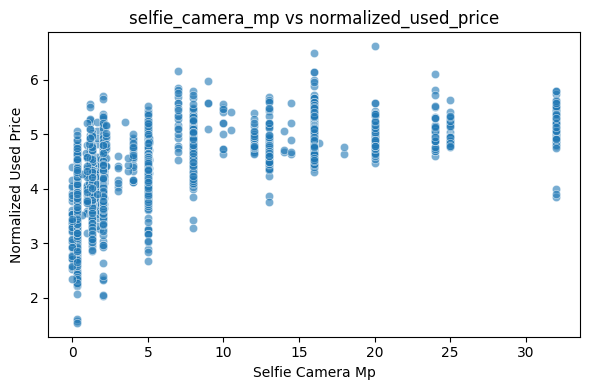

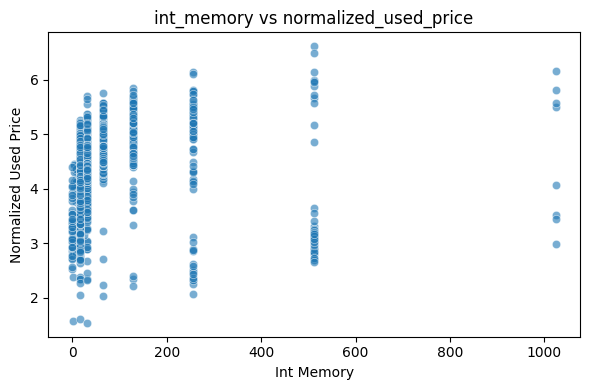

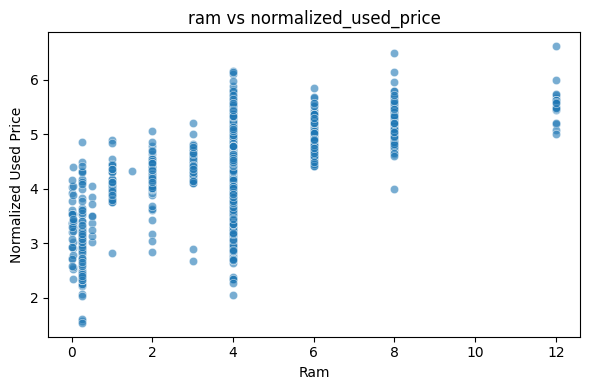

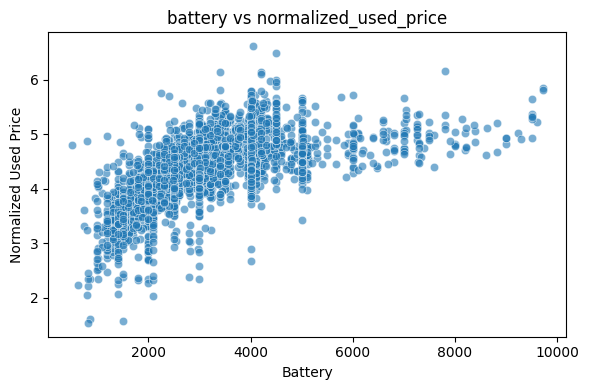

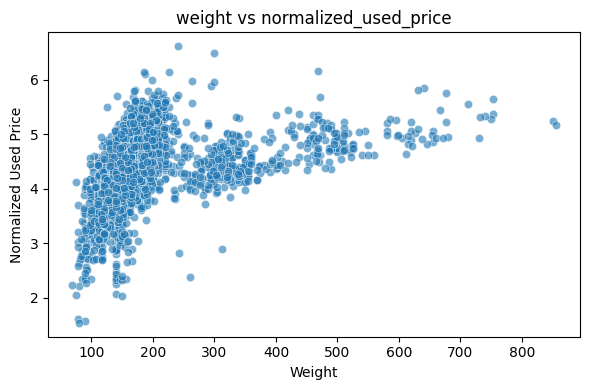

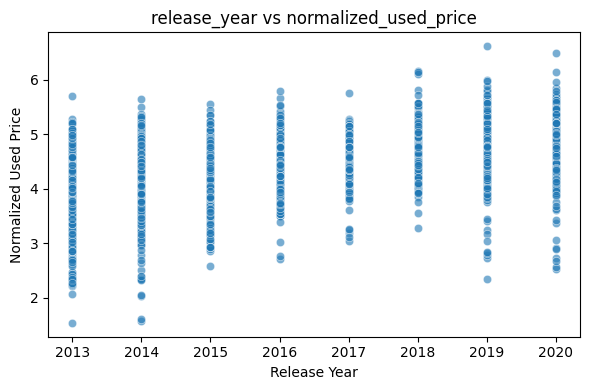

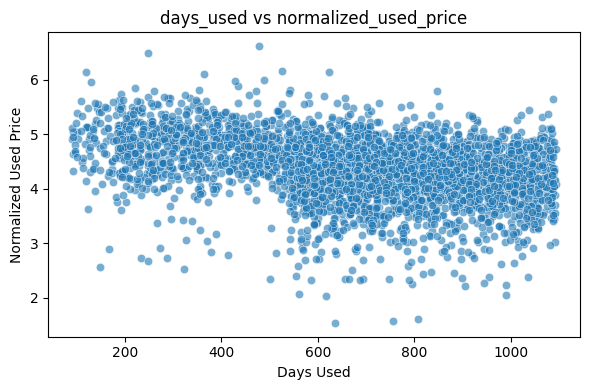

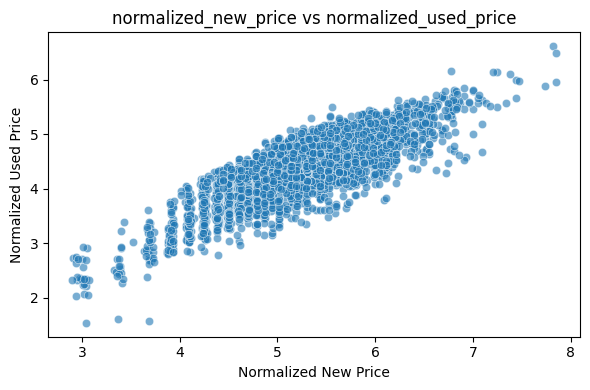

In [26]:
# Scatterplots Against Target Variable
target = "normalized_used_price"

predictors = [col for col in num_cols if col != target]

for col in predictors:
    plt.figure(figsize=(6, 4))

    sns.scatterplot(
        data=Recell_data,
        x=col,
        y=target,
        alpha=0.6
    )

    plt.title(f"{col} vs {target}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Normalized Used Price")
    plt.tight_layout()
    plt.show()

### Observations from the Scatter Plots

- The normalized new price exhibits the strongest positive linear relationship with the normalized used price, indicating that devices with higher original prices generally retain higher resale values.
- RAM, screen size, and battery capacity also show positive relationships with used price, suggesting that devices with better hardware specifications tend to command higher resale values in the secondary market.
- Release year has a moderate positive association with resale price, with newer devices generally selling for more than older models.
- Days used displays a weak negative relationship with used price, reflecting the expected depreciation of devices as their usage duration increases.
- Main camera resolution, selfie camera resolution, internal memory, and weight show weaker or non-linear relationships with resale price, indicating that these features alone are less reliable predictors of a device's value.
- Several variables exhibit considerable variability at similar feature values, suggesting that no single feature fully explains the resale price. Instead, used device prices are influenced by a combination of hardware specifications, device age, and original market price.

Overall, normalized new price, RAM, screen size, and battery capacity appear to be the most influential predictors of the normalized used price, while days used captures the depreciation effect. These relationships indicate that a multiple linear regression model incorporating several features is appropriate for predicting the resale price of used devices.


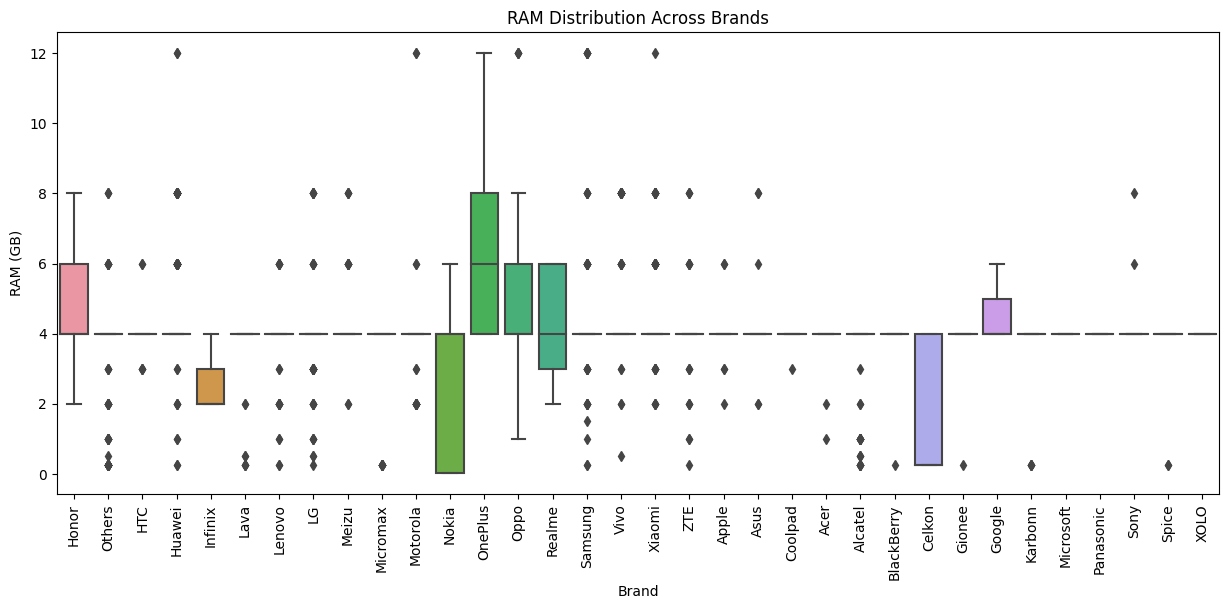

In [29]:
# RAM vs Brand

plt.figure(figsize=(15,6))

sns.boxplot(
    data=Recell_data,
    x="brand_name",
    y="ram"
)

plt.xticks(rotation=90)
plt.title("RAM Distribution Across Brands")
plt.xlabel("Brand")
plt.ylabel("RAM (GB)")

plt.show()

## Observations

- Across most brands, 4 GB RAM is the most common configuration, as indicated by the narrow boxplots centered around this value.
- Premium-oriented brands such as OnePlus, Oppo, Realme, and Honor generally offer devices with higher RAM capacities and greater variability, reflecting a wider range of mid-range and flagship models.
- Budget-focused brands, including Nokia, Celkon, and Infinix, tend to have lower RAM configurations, indicating an emphasis on entry-level devices.
- Several brands, such as Micromax, Coolpad, Gionee, Karbonn, Microsoft, Panasonic, BlackBerry, Spice, and XOLO, exhibit little variation in RAM capacity, suggesting a relatively standardized product lineup within the dataset.
- Outliers are present for many brands, indicating that most manufacturers produce devices across multiple market segments with varying RAM capacities rather than a single standard configuration.
- Overall, brand appears to be an important factor influencing RAM configuration, with premium brands generally offering higher memory capacities than budget-oriented brands.

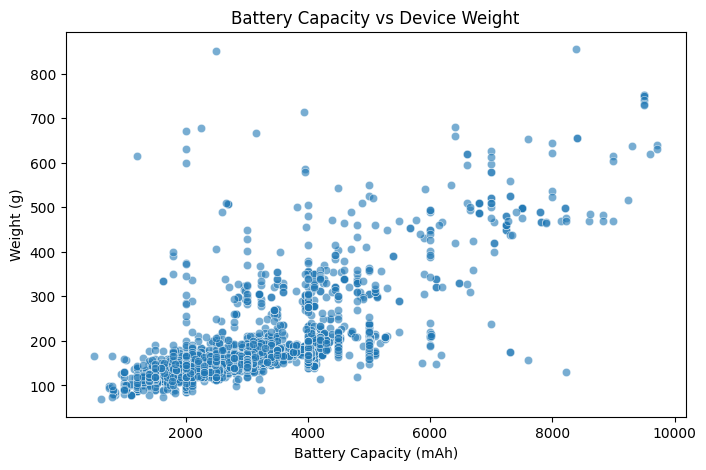

In [30]:
# Battery vs Weight
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=Recell_data,
    x="battery",
    y="weight",
    alpha=0.6
)

plt.title("Battery Capacity vs Device Weight")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Weight (g)")

plt.show()

## Observations

- Battery capacity and device weight exhibit a clear positive relationship, with devices generally becoming heavier as battery capacity increases.
- Most observations are concentrated among standard smartphones with battery capacities below 4,000 mAh and weights below 200 g.
- Greater variation in device weight is observed at higher battery capacities, suggesting that factors such as device type, build materials, and additional features also influence weight.
- A few notable outliers are present, including very heavy devices with relatively modest battery capacities and devices with exceptionally large batteries, which are likely tablets or specialized devices.

Overall, the relationship is positive but not perfectly linear, indicating that battery capacity is an important predictor of device weight, although additional variables may also contribute to explaining the variation.

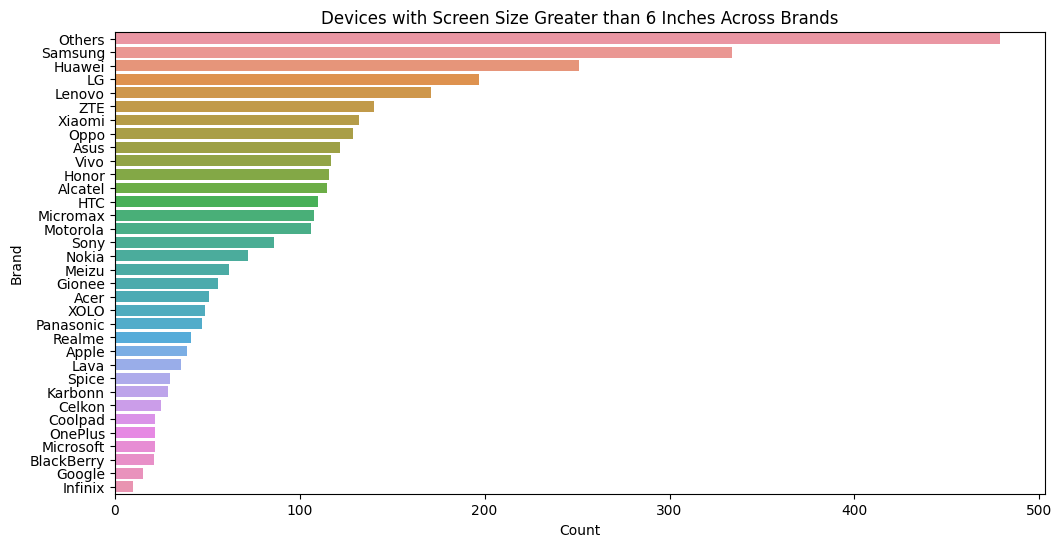

In [31]:
# Screen Size Greater than 6 Inches Across Brands
large_screen = Recell_data[Recell_data["screen_size"] > 6]

plt.figure(figsize=(12,6))

sns.countplot(
    data=large_screen,
    y="brand_name",
    order=large_screen["brand_name"].value_counts().index
)

plt.title("Devices with Screen Size Greater than 6 Inches Across Brands")
plt.xlabel("Count")
plt.ylabel("Brand")

plt.show()

## Observations

- The `Others` category has the highest number of devices with screen sizes greater than 6 inches, followed by Samsung, Huawei, and LG, indicating that these brands have the largest presence in the dataset.
- Several brands, including Lenovo, ZTE, Xiaomi, Oppo, Asus, Vivo, Honor, and Alcatel, also have a substantial number of devices with screens larger than 6 inches.
- Brands such as Sony, Nokia, Meizu, Gionee, Acer, XOLO, Panasonic, and Realme have comparatively fewer large-screen devices, while Apple, OnePlus, Google, Microsoft, BlackBerry, and Infinix have the lowest counts.
- The distribution of devices with screen sizes above 6 inches closely reflects the overall distribution of brands in the dataset, indicating that large-screen devices are common across most manufacturers.
  
Overall, a screen size greater than 6 inches is not a distinguishing characteristic for any particular brand, as it is a common feature across the majority of manufacturers represented in the dataset.

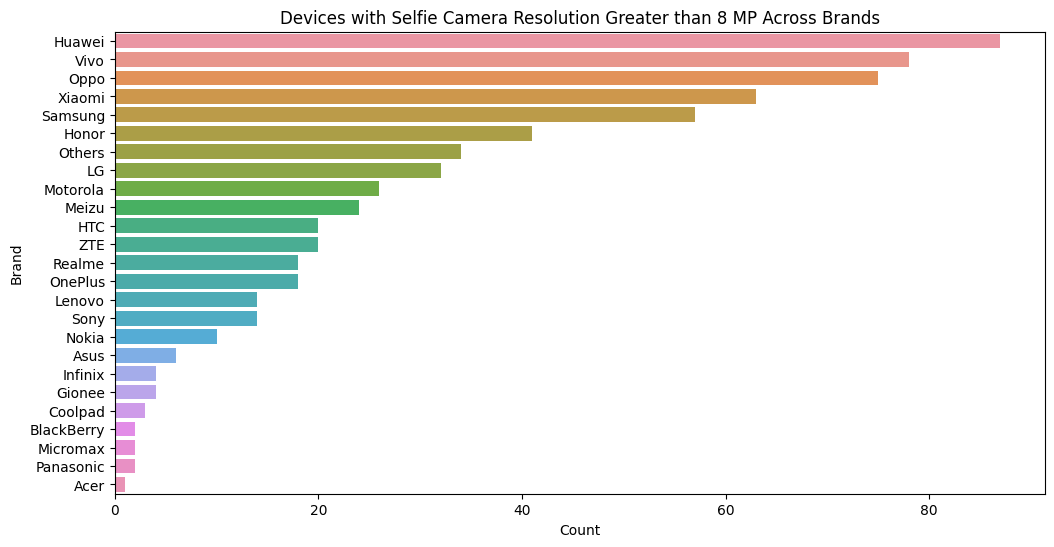

In [32]:
# Selfie Camera Greater than 8 MP Across Brands
good_selfie = Recell_data[Recell_data["selfie_camera_mp"] > 8]

plt.figure(figsize=(12,6))

sns.countplot(
    data=good_selfie,
    y="brand_name",
    order=good_selfie["brand_name"].value_counts().index
)

plt.title("Devices with Selfie Camera Resolution Greater than 8 MP Across Brands")
plt.xlabel("Count")
plt.ylabel("Brand")

plt.show()

## Observations

- Huawei has the highest number of devices with selfie camera resolutions above 8 MP, followed by Vivo, Oppo, Xiaomi, and Samsung, indicating that these brands have a strong presence in the high-resolution selfie camera segment.
- Honor, LG, Motorola, and the `Others` category also contribute a moderate number of devices with higher-resolution selfie cameras.
- Several brands, including Meizu, HTC, ZTE, Realme, OnePlus, Lenovo, and Sony, have a smaller but noticeable presence in this category.
- Brands such as Nokia, Asus, Infinix, Gionee, Coolpad, BlackBerry, Micromax, Panasonic, and Acer have relatively few devices with selfie cameras above 8 MP, suggesting that higher-resolution front cameras are less common in their product portfolios.
  
Overall, Huawei, Vivo, Oppo, Xiaomi, and Samsung appear to place greater emphasis on higher-resolution selfie cameras, while many other brands focus less on this feature.

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## EDA

- It is a good idea to explore the data once again after manipulating it.

## Model Building - Linear Regression

## Model Performance Check

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

## Final Model

## Actionable Insights and Recommendations

-


___